# Laboratorio 7 — análisis exploratorio, segmentación y predicción salarial

**CC3066 Data Science · ENEIC Personas · entrega final del 27/09/2026**

Este notebook responde las actividades 1–8 del enunciado. Usa Spark 3.5.x para la
preparación, las estadísticas y KMeans. Los cinco archivos se leen por separado
desde Excel con pandas y luego se convierten a DataFrames de Spark con tipos
explícitos. Los cálculos principales son no ponderados. Las cifras describen
**registros elegibles**, no estimaciones oficiales de la población guatemalteca.

Fuente: [INE, ENEIC](https://www.ine.gob.gt/encuesta-nacional-de-empleo-e-ingresos/).

In [1]:
from functools import reduce
from pathlib import Path
import gc
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import load_workbook
from IPython.display import display, Markdown
from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.stat import Correlation

spark = (SparkSession.builder.master("local[2]")
    .appName("Lab7_ENEIC_avance")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark:", spark.version)
assert spark.version.startswith("3.5."), "Este laboratorio requiere Spark 3.5.x"
sns.set_theme(style="whitegrid")

def encontrar_raiz():
    for ruta in (Path.cwd(), *Path.cwd().parents):
        if (ruta / "Laboratorio 7. Spark ML Lib (2026).pdf").exists():
            return ruta
    raise FileNotFoundError("Abra el notebook desde el repositorio del Laboratorio 7")

RAIZ = encontrar_raiz()
DATOS = RAIZ / "data" / "raw"
PARQUET = RAIZ / "data" / "parquet"
PARQUET.mkdir(parents=True, exist_ok=True)

Spark: 3.5.1


## 1. Carga, armonización y calidad de datos

`TRIMESTRE` se guarda tal como aparece. `periodo_archivo`, `anio_archivo`,
`trimestre_calendario` y `archivo_origen` provienen del nombre del archivo,
porque el código original de `TRIMESTRE` no es el trimestre calendario.
IV de 2025 contiene 302 columnas originales, mientras que los tres cortes
anteriores tienen 270; por eso se seleccionan columnas por **nombre** y se
utiliza `unionByName`.

In [2]:
ARCHIVOS = [
    ("2025T1", 2025, 1, "personas_2025T1.xlsx"),
    ("2025T2", 2025, 2, "personas_2025T2.xlsx"),
    ("2025T3", 2025, 3, "personas_2025T3.xlsx"),
    ("2025T4", 2025, 4, "personas_2025T4.xlsx"),
    ("2026T1", 2026, 1, "personas_2026T1.xlsx"),
]
ORIGINALES = [
    "P05D01", "P02A03", "P05C07A", "P05C07B", "P05H01A", "P03A03A",
    "P05C16", "DOMINIO", "OCUPADOS", "NUM_HOGAR", "NUM_PERSONA",
    "FACTOR", "ANIO", "TRIMESTRE",
]
faltan = [nombre for _, _, _, nombre in ARCHIVOS if not (DATOS / nombre).exists()]
if faltan:
    raise FileNotFoundError(
        "Faltan bases de Personas en data/raw/: " + ", ".join(faltan)
        + ". Ejecute scripts/descargar_datos.sh o copie allí los Excel oficiales."
    )

esquema = T.StructType([T.StructField(c, T.StringType(), True) for c in ORIGINALES])
def leer_personas(periodo, anio, trimestre, nombre):
    # usecols evita cargar en pandas las 270/302 columnas completas.
    pdf = pd.read_excel(
        DATOS / nombre, usecols=lambda c: str(c).strip().upper() in ORIGINALES,
        dtype=str, engine="openpyxl",
    )
    pdf.columns = [str(c).strip().upper() for c in pdf.columns]
    ausentes = sorted(set(ORIGINALES) - set(pdf.columns))
    if ausentes:
        raise ValueError(f"{nombre}: faltan columnas {ausentes}")
    pdf = pdf[ORIGINALES].astype(object).where(pd.notna(pdf), None)
    df = spark.createDataFrame(pdf, schema=esquema)
    cantidad = len(pdf)
    del pdf
    gc.collect()
    return (
        df.withColumn("periodo_archivo", F.lit(periodo))
          .withColumn("anio_archivo", F.lit(anio))
          .withColumn("trimestre_calendario", F.lit(trimestre))
          .withColumn("archivo_origen", F.lit(nombre)), cantidad
    )

cuadros = []
conteos_originales = {}
for especificacion in ARCHIVOS:
    cuadro, n = leer_personas(*especificacion)
    cuadros.append(cuadro)
    conteos_originales[especificacion[0]] = n
    print(especificacion[0], n, "filas originales")

raw25 = reduce(lambda a, b: a.unionByName(b), cuadros[:4]).cache()
raw26 = cuadros[4].cache()
print("Esquema seleccionado de 2025:")
raw25.printSchema()
display(raw25.limit(5).toPandas())
display(raw25.groupBy("periodo_archivo", "TRIMESTRE").count()
        .orderBy("periodo_archivo", "TRIMESTRE").toPandas())

2025T1 51588 filas originales


2025T2 51167 filas originales


2025T3 51583 filas originales


2025T4 49338 filas originales


2026T1 49843 filas originales


Esquema seleccionado de 2025:
root
 |-- P05D01: string (nullable = true)
 |-- P02A03: string (nullable = true)
 |-- P05C07A: string (nullable = true)
 |-- P05C07B: string (nullable = true)
 |-- P05H01A: string (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- DOMINIO: string (nullable = true)
 |-- OCUPADOS: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: string (nullable = true)
 |-- ANIO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- archivo_origen: string (nullable = false)



,P05D01,P02A03,P05C07A,P05C07B,P05H01A,P03A03A,P05C16,DOMINIO,OCUPADOS,NUM_HOGAR,NUM_PERSONA,FACTOR,ANIO,TRIMESTRE,periodo_archivo,anio_archivo,trimestre_calendario,archivo_origen
0,None,14,None,None,None,3,None,2,None,13796,3,338,2025,2,2025T1,2025,1,personas_2025T1.xlsx
1,None,42,23,0,35,5,6,2,1,13796,1,338,2025,2,2025T1,2025,1,personas_2025T1.xlsx
2,7000,42,20,0,1,5,1,2,1,13796,2,338,2025,2,2025T1,2025,1,personas_2025T1.xlsx
3,None,9,None,None,None,2,None,2,None,13796,5,338,2025,2,2025T1,2025,1,personas_2025T1.xlsx
4,None,11,None,None,None,2,None,2,None,13796,4,338,2025,2,2025T1,2025,1,personas_2025T1.xlsx


,periodo_archivo,TRIMESTRE,count
0,2025T1,2,51588
1,2025T2,2,175
2,2025T2,3,50992
3,2025T3,4,51583
4,2025T4,5,49338


In [3]:
def ausente(c):
    valor = F.upper(F.trim(F.col(c)))
    return F.col(c).isNull() | valor.isin("", "NAN", "NULL", "NONE")

total_bruto = raw25.count()
faltantes = raw25.agg(*[
    F.sum(F.when(ausente(c), 1).otherwise(0)).alias(c) for c in ORIGINALES
]).first().asDict()
tabla_faltantes = pd.DataFrame([
    {"variable": c, "faltantes": int(faltantes[c]),
     "porcentaje": round(100 * faltantes[c] / total_bruto, 2)}
    for c in ORIGINALES
])
display(tabla_faltantes)

,variable,faltantes,porcentaje
0,P05D01,150651,73.97
1,P02A03,0,0.00
2,P05C07A,115454,56.69
3,P05C07B,115454,56.69
4,P05H01A,115454,56.69
5,P03A03A,26344,12.93
6,P05C16,115454,56.69
7,DOMINIO,0,0.00
8,OCUPADOS,115454,56.69
9,NUM_HOGAR,0,0.00


Los campos fuera del módulo laboral pueden aparecer vacíos porque la pregunta
no corresponde a esa persona. Eso es distinto de una respuesta que sí debía
registrarse pero faltó. Para el análisis se informa el vacío, sin inferir la
causa individual a partir de una celda en blanco.

In [4]:
# Homologamos códigos que Excel puede leer como "1", "1.0" o texto.
def codigo(c):
    v = F.trim(F.col(c))
    return F.when(ausente(c), None).otherwise(
        F.regexp_replace(v, r"^([+-]?[0-9]+)\.0+$", "$1")
    )

def numero(c):
    return F.trim(F.col(c)).cast("double")

def finito(c):
    x = F.col(c)
    return x.isNotNull() & (~F.isnan(x)) & (x > F.lit(float("-inf"))) & (x < F.lit(float("inf")))

def armonizar(df):
    return (df
        .withColumn("edad", numero("P02A03"))
        .withColumn("antiguedad_anios", numero("P05C07A"))
        .withColumn("antiguedad_meses", numero("P05C07B"))
        .withColumn("horas_semanales", numero("P05H01A"))
        .withColumn("salario_mensual", numero("P05D01"))
        .withColumn("nivel_educativo", codigo("P03A03A"))
        .withColumn("categoria_ocupacional", codigo("P05C16"))
        .withColumn("dominio", codigo("DOMINIO"))
        .withColumn("ocupado", codigo("OCUPADOS"))
        .withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0))
    )

armon25 = armonizar(raw25)
armon26 = armonizar(raw26)
print("Esquema analítico homologado:")
armon25.select("periodo_archivo", "edad", "antiguedad", "horas_semanales",
              "salario_mensual", "nivel_educativo", "categoria_ocupacional",
              "dominio").printSchema()
display(armon25.select("periodo_archivo", "edad", "antiguedad",
                       "horas_semanales", "salario_mensual", "nivel_educativo",
                       "categoria_ocupacional", "dominio").limit(5).toPandas())

Esquema analítico homologado:
root
 |-- periodo_archivo: string (nullable = false)
 |-- edad: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)



,periodo_archivo,edad,antiguedad,horas_semanales,salario_mensual,nivel_educativo,categoria_ocupacional,dominio
0,2025T1,14.0,NaN,NaN,NaN,3,None,2
1,2025T1,42.0,23.0,35.0,NaN,5,6,2
2,2025T1,42.0,20.0,1.0,7000.0,5,1,2
3,2025T1,9.0,NaN,NaN,NaN,2,None,2
4,2025T1,11.0,NaN,NaN,NaN,2,None,2


In [5]:
# Auditoría de claves: una persona en trimestres distintos son dos observaciones.
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
def auditar_claves(df, nombre):
    sin_clave = df.filter(reduce(lambda a,b: a | b, [ausente(c) for c in CLAVE])).count()
    duplicadas = df.groupBy(*CLAVE).count().filter(F.col("count") > 1)
    grupos = duplicadas.count()
    filas = duplicadas.agg(F.sum("count")).first()[0] or 0
    print(f"{nombre}: claves incompletas={sin_clave}; grupos duplicados={grupos}; filas involucradas={filas}")
    if grupos:
        datos = df.join(duplicadas.select(*CLAVE), CLAVE, "inner")
        huellas = datos.withColumn(
            "huella", F.to_json(F.struct(*[F.col(c) for c in df.columns if c not in CLAVE]))
        )
        detalle = (huellas.groupBy(*CLAVE)
            .agg(F.count("*").alias("filas"), F.countDistinct("huella").alias("versiones"))
            .withColumn("tipo", F.when(F.col("versiones") == 1, "repetición exacta").otherwise("conflicto")))
        display(detalle.groupBy("tipo").count().toPandas())
        display(detalle.limit(100).toPandas())
    return grupos

duplicados25 = auditar_claves(raw25, "2025")
duplicados26 = auditar_claves(raw26, "2026T1")

2025: claves incompletas=0; grupos duplicados=0; filas involucradas=0


2026T1: claves incompletas=0; grupos duplicados=0; filas involucradas=0


In [6]:
# Los filtros siempre siguen este orden, por lo que cada exclusión se cuenta una sola vez.
FILTROS = [
    ("edad finita >= 15", lambda d: finito("edad") & (F.col("edad") >= 15)),
    ("OCUPADOS = 1", lambda d: F.col("ocupado") == "1"),
    ("P05C16 en 1,2,3,4", lambda d: F.col("categoria_ocupacional").isin("1", "2", "3", "4")),
    ("salario finito > 0", lambda d: finito("salario_mensual") & (F.col("salario_mensual") > 0)),
    ("antigüedad años finita >= 0", lambda d: finito("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)),
    ("meses enteros de 0 a 11", lambda d: finito("antiguedad_meses") & F.col("antiguedad_meses").between(0, 11) & (F.col("antiguedad_meses") == F.floor("antiguedad_meses"))),
    ("antigüedad total <= edad", lambda d: F.col("antiguedad") <= F.col("edad")),
    ("horas finitas en (0,168]", lambda d: finito("horas_semanales") & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168)),
]
def filtrar_con_auditoria(df, nombre):
    actual = df
    auditoria = []
    anterior = actual.count()
    for etiqueta, condicion in FILTROS:
        actual = actual.filter(condicion(actual))
        nuevo = actual.count()
        auditoria.append({"periodo": nombre, "filtro": etiqueta, "excluidos": anterior - nuevo, "restantes": nuevo})
        anterior = nuevo
    return actual, pd.DataFrame(auditoria)

base25, audit25 = filtrar_con_auditoria(armon25, "2025")
base26, audit26 = filtrar_con_auditoria(armon26, "2026T1")
display(pd.concat([audit25, audit26], ignore_index=True))

,periodo,filtro,excluidos,restantes
0,2025,edad finita >= 15,62886,140790
1,2025,OCUPADOS = 1,52568,88222
2,2025,"P05C16 en 1,2,3,4",35197,53025
3,2025,salario finito > 0,0,53025
4,2025,antigüedad años finita >= 0,0,53025
5,2025,meses enteros de 0 a 11,0,53025
6,2025,antigüedad total <= edad,0,53025
7,2025,"horas finitas en (0,168]",0,53025
8,2026T1,edad finita >= 15,14803,35040
9,2026T1,OCUPADOS = 1,13306,21734


In [7]:
# La celda muestra los códigos presentes para detectar diferencias entre cortes.
for variable in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    print(variable)
    display(base25.groupBy("periodo_archivo", variable).count().orderBy("periodo_archivo", variable).toPandas())

# Leemos los códigos válidos de la sección "Valores de variable" de cada
# diccionario oficial, sin inventar rangos. Educación 0 = NINGUNO.
def codigos_diccionario(ruta, variables):
    hoja = load_workbook(ruta, read_only=True, data_only=True).active
    mapas = {variable: {} for variable in variables}
    en_valores = False
    actual = None
    for fila in hoja.values:
        primera = str(fila[0]).strip() if fila[0] is not None else None
        if primera == "Valores de variable":
            en_valores = True
            continue
        if not en_valores:
            continue
        if primera is not None:
            actual = primera if primera in mapas else None
        if actual is not None and fila[1] is not None:
            codigo_valor = fila[1]
            clave = str(int(codigo_valor)) if isinstance(codigo_valor, (int, float)) and float(codigo_valor).is_integer() else str(codigo_valor).strip()
            mapas[actual][clave] = str(fila[2]).strip() if fila[2] is not None else clave
    hoja.parent.close()
    for variable, mapa in mapas.items():
        if not mapa:
            raise ValueError(f"No se hallaron códigos de {variable} en {ruta}")
    return mapas

DICCIONARIOS = {}
for periodo, _, _, _ in ARCHIVOS:
    ruta = DATOS / f"diccionario_{periodo}.xlsx"
    if not ruta.exists():
        raise FileNotFoundError(f"Falta el diccionario oficial {ruta.name}")
    DICCIONARIOS[periodo] = codigos_diccionario(
        ruta, ["P03A03A", "P05C16", "DOMINIO"]
    )
print("Códigos y etiquetas del diccionario 2025T1:")
for variable, mapa in DICCIONARIOS["2025T1"].items():
    print(variable, mapa)
assert DICCIONARIOS["2025T1"]["P03A03A"].get("0", "").upper() == "NINGUNO"

VALIDACION = {
    "nivel_educativo": "P03A03A",
    "categoria_ocupacional": "P05C16",
    "dominio": "DOMINIO",
}

def categorizar(df):
    for variable, nombre_diccionario in VALIDACION.items():
        valido = F.lit(False)
        for periodo, mapas in DICCIONARIOS.items():
            valido = valido | (
                (F.col("periodo_archivo") == periodo)
                & F.col(variable).isin(sorted(mapas[nombre_diccionario]))
            )
        df = df.withColumn(variable, F.when(valido, F.col(variable)).otherwise("DESCONOCIDO"))
    return df

base25 = categorizar(base25).cache()
base26 = categorizar(base26).cache()
por_archivo = (base25.groupBy("periodo_archivo").count()
    .unionByName(base26.groupBy("periodo_archivo").count())
    .toPandas().rename(columns={"count": "despues_filtros"}))
por_archivo["antes_filtros"] = por_archivo["periodo_archivo"].map(conteos_originales)
por_archivo["excluidos"] = por_archivo["antes_filtros"] - por_archivo["despues_filtros"]
display(por_archivo.sort_values("periodo_archivo"))

base25.write.mode("overwrite").parquet(str(PARQUET / "personas_2025_preparado"))
base26.write.mode("overwrite").parquet(str(PARQUET / "personas_2026T1_preparado"))
print("Parquet preparados guardados en", PARQUET)

nivel_educativo


,periodo_archivo,nivel_educativo,count
0,2025T1,0,1050
1,2025T1,1,138
2,2025T1,2,4062
3,2025T1,3,2079
4,2025T1,4,4196
5,2025T1,5,1674
6,2025T1,6,202
7,2025T1,7,18
8,2025T2,0,1044
9,2025T2,1,122


categoria_ocupacional


,periodo_archivo,categoria_ocupacional,count
0,2025T1,1,1623
1,2025T1,2,6825
2,2025T1,3,4057
3,2025T1,4,914
4,2025T2,1,1634
5,2025T2,2,7136
6,2025T2,3,3702
7,2025T2,4,1020
8,2025T3,1,1681
9,2025T3,2,7566


dominio


,periodo_archivo,dominio,count
0,2025T1,1,5481
1,2025T1,2,5167
2,2025T1,3,2771
3,2025T2,1,5581
4,2025T2,2,5175
5,2025T2,3,2736
6,2025T3,1,5690
7,2025T3,2,5076
8,2025T3,3,2684
9,2025T4,1,5320


Códigos y etiquetas del diccionario 2025T1:
P03A03A {'0': 'NINGUNO', '1': 'PREPRIMARIA', '2': 'PRIMARIA', '3': 'BÁSICO', '4': 'DIVERSIFICADO', '5': 'SUPERIOR', '6': 'MAESTRÍA', '7': 'DOCTORADO'}
P05C16 {'1': 'Empleado de gobierno?', '2': 'Empleado de empresa privada?', '3': 'Empleado jornalero o peón?', '4': 'Del servicio doméstico?', '5': 'Trabajador por cuenta propia NO agrícola?', '6': 'Patrón empleador (a) socio (a) NO agrícola?', '7': 'Trabajador por cuenta propia agrícola?', '8': 'Patrón empleador (a) socio (a) agrícola?', '9': 'Trabajador No remunerado?'}
DOMINIO {'1': 'Urbano Metropolitano', '2': 'Resto Urbano', '3': 'Rural Nacional'}


,periodo_archivo,despues_filtros,antes_filtros,excluidos
0,2025T1,13419,51588,38169
1,2025T2,13492,51167,37675
2,2025T3,13450,51583,38133
3,2025T4,12664,49338,36674
4,2026T1,13258,49843,36585


Parquet preparados guardados en /Users/jorgelopez/Downloads/Lab7-DataScience/data/parquet


La base filtrada excluye personas menores de 15, no ocupadas, no asalariadas y
salarios ausentes o no positivos. Además, hay diseño muestral y observaciones
longitudinales: el número de filas no equivale a personas únicas ni al total
nacional de trabajadores. Una persona observada en dos períodos se conserva
porque son mediciones en momentos distintos. `FACTOR` serviría para expandir
a la población dentro de un análisis que respete el diseño de la encuesta;
aquí no se aplica ponderación, según el alcance del laboratorio.

## 2. Estadística descriptiva de 2025

Las medias, desviaciones y extremos se calculan sobre todas las filas elegibles.
Los percentiles usan `percentile_approx` de Spark con precisión 10000, también
sobre el conjunto completo. No se recortan salarios extremos.

In [8]:
VARIABLES_NUM = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
def descriptivos(df):
    salida = []
    for c in VARIABLES_NUM:
        fila = df.agg(
            F.count(c).alias("n"), F.avg(c).alias("media"),
            F.stddev_samp(c).alias("desviacion"),
            F.min(c).alias("minimo"), F.max(c).alias("maximo"),
            F.percentile_approx(c, [0.25, 0.5, 0.75, 0.95], 10000).alias("p"),
        ).first()
        salida.append({"variable": c, "n": fila.n, "media": fila.media,
                       "mediana": fila.p[1], "desviacion": fila.desviacion,
                       "minimo": fila.minimo, "maximo": fila.maximo,
                       "p25": fila.p[0], "p75": fila.p[2], "p95": fila.p[3]})
    return pd.DataFrame(salida)

resumen = descriptivos(base25)
display(resumen.round(2))
sal = resumen.set_index("variable").loc["salario_mensual"]
sesgo = "mayor" if sal["media"] > sal["mediana"] else "menor"
forma = "asimetría hacia salarios altos" if sal["media"] > sal["mediana"] else "asimetría hacia salarios bajos"
display(Markdown(
    f"**Interpretación.** El salario medio (Q {sal['media']:,.2f}) es {sesgo} "
    f"que la mediana (Q {sal['mediana']:,.2f}); la diferencia es "
    f"Q {abs(sal['media']-sal['mediana']):,.2f}. El histograma y esta diferencia "
    f"son consistentes con **{forma}**; p95 = Q {sal['p95']:,.2f} y "
    f"máximo = Q {sal['maximo']:,.2f}. Los extremos se conservan."
))

,variable,n,media,mediana,desviacion,minimo,maximo,p25,p75,p95
0,salario_mensual,53025,3421.68,3000.0,2902.11,1.0,99000.0,1800.0,4000.0,8000.0
1,edad,53025,35.19,33.0,13.52,15.0,89.0,24.0,44.0,61.0
2,antiguedad,53025,5.56,2.0,7.83,0.0,70.0,0.5,7.0,22.0
3,horas_semanales,53025,46.31,45.0,18.63,1.0,126.0,40.0,55.0,80.0


**Interpretación.** El salario medio (Q 3,421.68) es mayor que la mediana (Q 3,000.00); la diferencia es Q 421.68. El histograma y esta diferencia son consistentes con **asimetría hacia salarios altos**; p95 = Q 8,000.00 y máximo = Q 99,000.00. Los extremos se conservan.

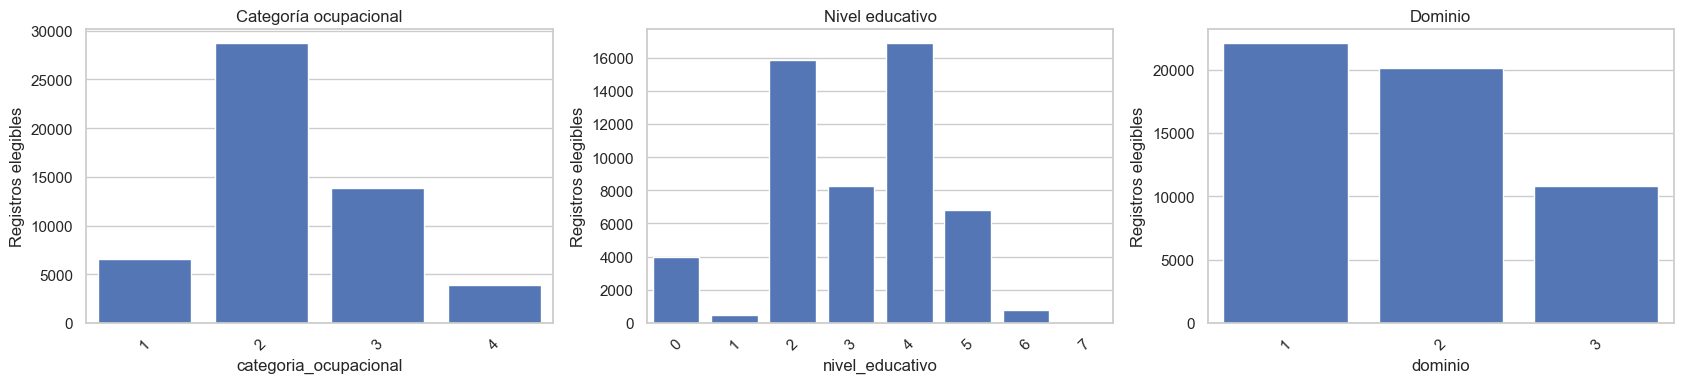

**Categorías más frecuentes.** categoría ocupacional: código 2 (28,702 registros); nivel educativo: código 4 (16,851 registros); dominio: código 1 (22,072 registros).

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
principales = []
for ax, variable, titulo in zip(
    axes, ["categoria_ocupacional", "nivel_educativo", "dominio"],
    ["Categoría ocupacional", "Nivel educativo", "Dominio"],
):
    t = base25.groupBy(variable).count().orderBy(variable).toPandas()
    fila_mayor = t.sort_values("count", ascending=False).iloc[0]
    principales.append(f"{titulo.lower()}: código {fila_mayor[variable]} ({int(fila_mayor['count']):,} registros)")
    sns.barplot(data=t, x=variable, y="count", ax=ax, color="#4472c4")
    ax.set_title(titulo)
    ax.set_ylabel("Registros elegibles")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
display(Markdown("**Categorías más frecuentes.** " + "; ".join(principales) + "."))

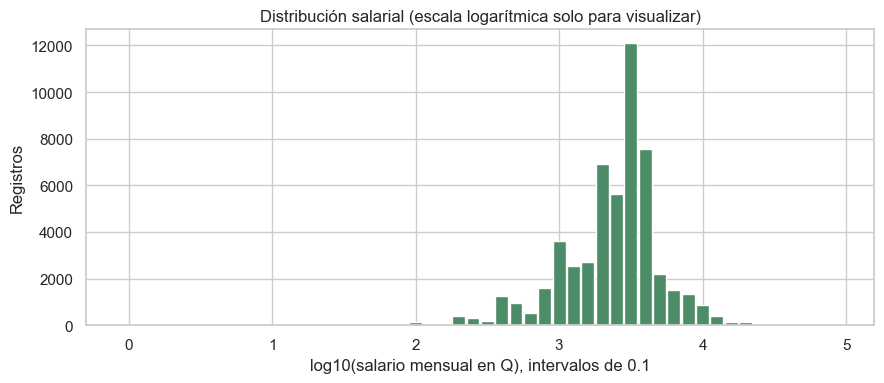

In [10]:
# Histograma agregado en Spark con intervalos de log10(salario), sin bajar filas.
hist = (base25.withColumn("intervalo_log10", F.floor(F.log10("salario_mensual") * 10) / 10)
    .groupBy("intervalo_log10").count().orderBy("intervalo_log10").toPandas())
plt.figure(figsize=(9, 4))
plt.bar(hist["intervalo_log10"], hist["count"], width=0.09, color="#4c8c66")
plt.xlabel("log10(salario mensual en Q), intervalos de 0.1")
plt.ylabel("Registros")
plt.title("Distribución salarial (escala logarítmica solo para visualizar)")
plt.tight_layout()
plt.show()

,nivel_educativo,n,mediana_Q
0,0,3995,1500.0
1,1,459,2160.0
2,2,15822,2200.0
3,3,8249,2800.0
4,4,16851,3600.0
5,5,6818,5000.0
6,6,771,10000.0
7,7,60,12000.0


,categoria_ocupacional,n,mediana_Q
0,1,6575,5000.0
1,2,28702,3560.0
2,3,13842,1800.0
3,4,3906,1000.0


,periodo_archivo,n,mediana_Q
0,2025T1,13419,3000.0
1,2025T2,13492,3000.0
2,2025T3,13450,3200.0
3,2025T4,12664,3200.0


**Lectura de grupos.** La mediana educativa más alta corresponde al código 7 (Q 12,000.00; n=60); en ocupación, al código 1 (Q 5,000.00; n=6,575). De 2025T1 a 2025T4 la muestra elegible cambia de 13,419 a 12,664 registros y la mediana de Q 3,000.00 a Q 3,200.00. Los códigos se interpretan con los diccionarios oficiales.

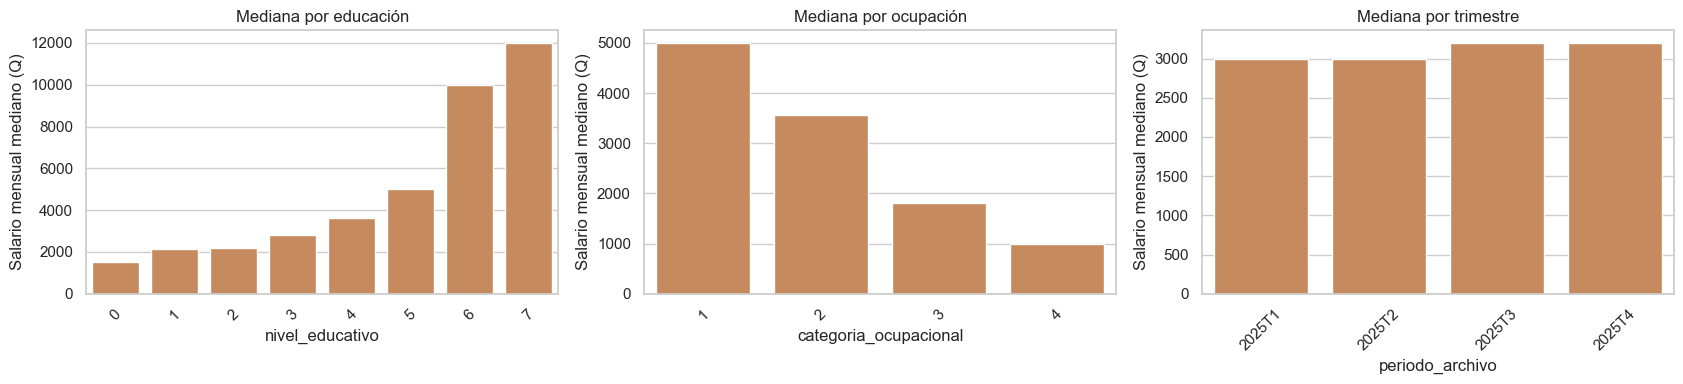

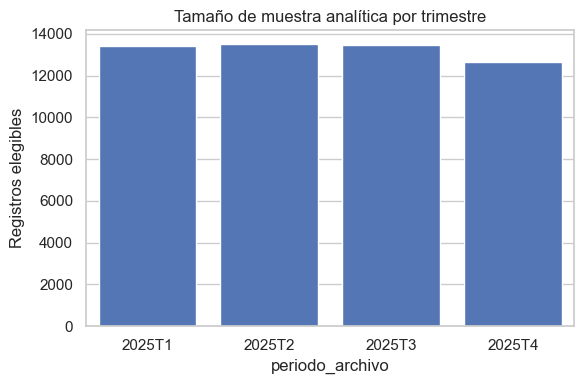

In [11]:
def mediana_por(grupos):
    return (base25.groupBy(*grupos)
        .agg(F.count("*").alias("n"),
             F.percentile_approx("salario_mensual", 0.5, 10000).alias("mediana_Q"))
        .orderBy(*grupos).toPandas())

por_educacion = mediana_por(["nivel_educativo"])
por_ocupacion = mediana_por(["categoria_ocupacional"])
por_trimestre = mediana_por(["periodo_archivo"])
display(por_educacion)
display(por_ocupacion)
display(por_trimestre)
ed_max = por_educacion.sort_values("mediana_Q", ascending=False).iloc[0]
oc_max = por_ocupacion.sort_values("mediana_Q", ascending=False).iloc[0]
tri_inicial = por_trimestre.set_index("periodo_archivo").loc["2025T1"]
tri_final = por_trimestre.set_index("periodo_archivo").loc["2025T4"]
display(Markdown(
    f"**Lectura de grupos.** La mediana educativa más alta corresponde al código "
    f"{ed_max['nivel_educativo']} (Q {ed_max['mediana_Q']:,.2f}; n={int(ed_max['n']):,}); "
    f"en ocupación, al código {oc_max['categoria_ocupacional']} "
    f"(Q {oc_max['mediana_Q']:,.2f}; n={int(oc_max['n']):,}). "
    f"De 2025T1 a 2025T4 la muestra elegible cambia de {int(tri_inicial['n']):,} "
    f"a {int(tri_final['n']):,} registros y la mediana de "
    f"Q {tri_inicial['mediana_Q']:,.2f} a Q {tri_final['mediana_Q']:,.2f}. "
    "Los códigos se interpretan con los diccionarios oficiales."
))
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, datos, columna, titulo in [
    (axes[0], por_educacion, "nivel_educativo", "Mediana por educación"),
    (axes[1], por_ocupacion, "categoria_ocupacional", "Mediana por ocupación"),
    (axes[2], por_trimestre, "periodo_archivo", "Mediana por trimestre"),
]:
    sns.barplot(data=datos, x=columna, y="mediana_Q", ax=ax, color="#d6884d")
    ax.set_title(titulo)
    ax.set_ylabel("Salario mensual mediano (Q)")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=por_trimestre, x="periodo_archivo", y="n", ax=ax, color="#4472c4")
ax.set_ylabel("Registros elegibles")
ax.set_title("Tamaño de muestra analítica por trimestre")
plt.tight_layout()
plt.show()

Las medianas por grupo son asociaciones descriptivas. Las diferencias entre
trimestres combinan cambios de muestra, composición laboral y salarios; no
demuestran por sí solas una tendencia causal. Los códigos de educación,
ocupación y dominio deben interpretarse con el diccionario del INE.

## 3. Relaciones lineales entre variables numéricas

Se usa Pearson mediante `VectorAssembler` y `Correlation.corr` sobre **todos**
los registros elegibles de 2025. La correlación no mide causalidad.

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


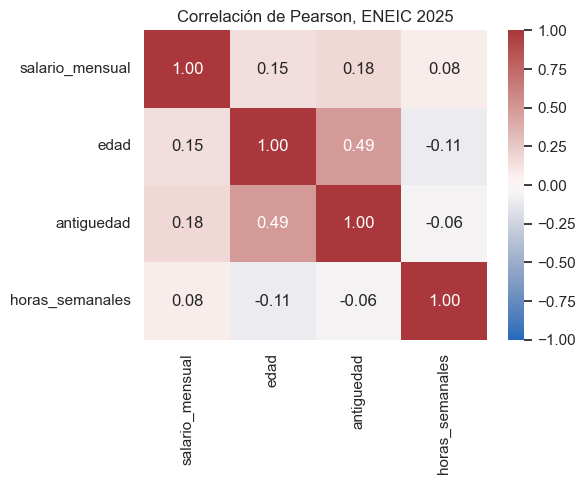

**Interpretación.** La asociación lineal absoluta más alta con salario es **antiguedad** (r = 0.180). Edad y antigüedad tienen r = 0.487. La magnitud describe asociación lineal, sin establecer causalidad.

In [12]:
columnas_corr = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
vector_corr = VectorAssembler(inputCols=columnas_corr, outputCol="variables_corr")
datos_corr = vector_corr.transform(base25.select(*columnas_corr)).select("variables_corr")
matriz = Correlation.corr(datos_corr, "variables_corr", "pearson").first()[0].toArray()
correlaciones = pd.DataFrame(matriz, index=columnas_corr, columns=columnas_corr)
display(correlaciones.round(3))
plt.figure(figsize=(6, 5))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Correlación de Pearson, ENEIC 2025")
plt.tight_layout()
plt.show()
asociaciones = correlaciones.loc["salario_mensual"].drop("salario_mensual").abs().sort_values(ascending=False)
display(Markdown(
    f"**Interpretación.** La asociación lineal absoluta más alta con salario es "
    f"**{asociaciones.index[0]}** (r = {correlaciones.loc['salario_mensual', asociaciones.index[0]]:.3f}). "
    f"Edad y antigüedad tienen r = {correlaciones.loc['edad', 'antiguedad']:.3f}. "
    "La magnitud describe asociación lineal, sin establecer causalidad."
))

## 4. Segmentación de perfiles con KMeans

Se agrupa por edad, antigüedad y horas habituales. **El salario se excluye**
del ajuste para descubrir perfiles laborales sin hacer que el objetivo domine
los grupos; se compara después entre clústeres. Las tres variables se
estandarizan. Se prueban K = 2, 3, 4 y 5 con semilla fija. Seleccionamos el
K de mayor silhouette (distancia euclidiana cuadrada) entre las soluciones
cuyo clúster menor tenga al menos 5 % de registros; si ninguna cumple,
seleccionamos el mayor silhouette disponible.

In [13]:
CLUSTER_VARS = ["edad", "antiguedad", "horas_semanales"]
ensamblador = VectorAssembler(inputCols=CLUSTER_VARS, outputCol="cluster_sin_escalar")
ensamblados = ensamblador.transform(base25)
escalador = StandardScaler(inputCol="cluster_sin_escalar", outputCol="cluster_features", withMean=True, withStd=True)
modelo_escala = escalador.fit(ensamblados)
escalados = modelo_escala.transform(ensamblados).cache()
evaluador = ClusteringEvaluator(featuresCol="cluster_features", predictionCol="cluster", metricName="silhouette", distanceMeasure="squaredEuclidean")
N = escalados.count()
resultados_k = []
modelos_k = {}
for k in (2, 3, 4, 5):
    modelo = KMeans(k=k, seed=42, featuresCol="cluster_features", predictionCol="cluster", maxIter=50).fit(escalados)
    pred = modelo.transform(escalados).cache()
    tamanos = [r["count"] for r in pred.groupBy("cluster").count().collect()]
    silueta = evaluador.evaluate(pred)
    resultados_k.append({"k": k, "silhouette": silueta,
                         "minimo_n": min(tamanos), "minimo_pct": 100 * min(tamanos) / N})
    modelos_k[k] = modelo
    pred.unpersist()
tabla_k = pd.DataFrame(resultados_k)
display(tabla_k.round(3))
admisibles = tabla_k.loc[tabla_k["minimo_pct"] >= 5]
if admisibles.empty:
    admisibles = tabla_k
mejor_k = int(admisibles.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
print("K seleccionado:", mejor_k)
perfiles = modelos_k[mejor_k].transform(escalados).cache()

,k,silhouette,minimo_n,minimo_pct
0,2,0.554,14604,27.542
1,3,0.420,7615,14.361
2,4,0.475,6846,12.911
3,5,0.491,2615,4.932


K seleccionado: 2


,cluster,n,media_edad,media_antiguedad,media_horas_semanales,salario_mediano_Q,porcentaje
0,0,38421,29.07,2.42,48.21,3000.0,72.46
1,1,14604,51.28,13.81,41.30,3456.0,27.54


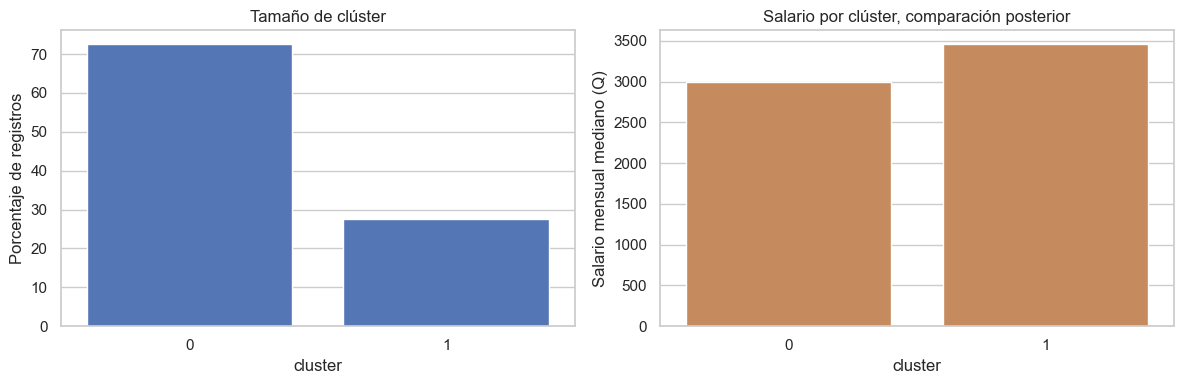

**Perfiles observados**

- **Clúster 0** (72.5%): menor edad, menor antigüedad, similar jornada frente al promedio general; salario mediano Q 3,000.00.
- **Clúster 1** (27.5%): mayor edad, mayor antigüedad, similar jornada frente al promedio general; salario mediano Q 3,456.00.

In [14]:
perfil = (perfiles.groupBy("cluster")
    .agg(F.count("*").alias("n"),
         *[F.avg(c).alias("media_" + c) for c in CLUSTER_VARS],
         F.percentile_approx("salario_mensual", 0.5, 10000).alias("salario_mediano_Q"))
    .orderBy("cluster").toPandas())
perfil["porcentaje"] = (100 * perfil["n"] / N).round(2)
display(perfil.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=perfil, x="cluster", y="porcentaje", ax=axes[0], color="#4472c4")
axes[0].set_ylabel("Porcentaje de registros")
axes[0].set_title("Tamaño de clúster")
sns.barplot(data=perfil, x="cluster", y="salario_mediano_Q", ax=axes[1], color="#d6884d")
axes[1].set_ylabel("Salario mensual mediano (Q)")
axes[1].set_title("Salario por clúster, comparación posterior")
plt.tight_layout()
plt.show()

globales = {
    c: base25.agg(F.avg(c).alias("media"), F.stddev_samp(c).alias("desv")).first()
    for c in CLUSTER_VARS
}
descripciones = []
for _, fila in perfil.iterrows():
    rasgos = []
    for c, nombre in [("edad", "edad"), ("antiguedad", "antigüedad"), ("horas_semanales", "jornada")]:
        valor = fila["media_" + c]
        z = (valor - globales[c]["media"]) / globales[c]["desv"]
        comparacion = "mayor" if z > 0.3 else "menor" if z < -0.3 else "similar"
        rasgos.append(comparacion + " " + nombre)
    descripciones.append(
        f"- **Clúster {int(fila['cluster'])}** ({fila['porcentaje']:.1f}%): "
        + ", ".join(rasgos) + f" frente al promedio general; "
        + f"salario mediano Q {fila['salario_mediano_Q']:,.2f}."
    )
display(Markdown("**Perfiles observados**\n\n" + "\n".join(descripciones)))

### Cierre de las actividades 1–4

El K elegido resume perfiles de edad, experiencia y jornada dentro de la
muestra analítica. Las medianas salariales por clúster sirven para describir
diferencias, sin sugerir que pertenecer a un grupo cause un salario. Los
salarios extremos permanecen en todas las estadísticas principales. A continuación se usan los Parquet preparados para ajustar y comparar los
modelos supervisados; 2026T1 se reserva para la prueba final.

### Hallazgos del análisis exploratorio

- De 203,676 registros originales de 2025, 53,025 cumplen todos los criterios.
  En 2026T1 hay 13,258 registros elegibles, reservados para la prueba final.
  No se encontraron claves duplicadas ni incompletas con la combinación
  `periodo_archivo`, `NUM_HOGAR` y `NUM_PERSONA`.
- En 2025, el salario mensual tiene mediana Q 3,000, media Q 3,421.68,
  percentil 95 Q 8,000 y máximo Q 99,000. La cola alta eleva la media;
  por ello las cifras centrales deben leerse junto con los extremos.
- La mediana de los registros con nivel educativo **ninguno** (código 0)
  es Q 1,500, frente a Q 5,000 para **superior** (código 5).
  **Doctorado** (código 7) alcanza Q 12,000, pero solo cuenta con 60
  registros; esa mediana tiene poca estabilidad. Entre ocupaciones,
  gobierno registra Q 5,000 y servicio doméstico Q 1,000.
- La muestra trimestral baja de 13,419 registros en 2025T1 a 12,664
  en 2025T4. La mediana salarial pasa de Q 3,000 a Q 3,200.
- La asociación lineal más alta con salario entre las variables numéricas
  es antigüedad (r = 0.180), seguida de edad (r = 0.147) y horas
  semanales (r = 0.076). Edad y antigüedad sí se relacionan moderadamente
  entre sí (r = 0.487).
- K=2 obtuvo silhouette 0.554. El clúster 0 agrupa 72.46 % de los
  registros, con edad media 29.07 años, antigüedad media 2.42 años,
  48.21 horas semanales y salario mediano Q 3,000. El clúster 1 agrupa
  27.54 %, con 51.28 años de edad media, 13.81 años de antigüedad,
  41.30 horas semanales y salario mediano Q 3,456. La segmentación se
  hizo sin salario; las diferencias salariales son una comparación posterior.

Estas asociaciones se refieren a los registros elegibles, sin ponderación
muestral. No indican causalidad ni salarios recomendados.

## 5 y 6. Modelos supervisados: regresión lineal y Random Forest

Se estimará `salario_mensual` en quetzales, sin transformarlo ni recortar extremos. Los **seis predictores exactos** son edad, antigüedad, horas semanales, nivel educativo, categoría ocupacional y dominio. La referencia predice siempre la **media salarial del conjunto de entrenamiento**. Los trimestres 2025T1–T3 forman entrenamiento y 2025T4 sirve únicamente para seleccionar configuraciones. El pipeline completo (índices, codificación y estimador) se ajusta solo con entrenamiento. 2026T1 permanece reservado para la evaluación final.

La regresión lineal usa su estandarización interna (`standardization=True`); Random Forest no necesita escalar. Ambos aplican `StringIndexer` y `OneHotEncoder` a las tres categorías y `VectorAssembler` a las tres variables numéricas y a las categorías codificadas. `handleInvalid="keep"` conserva categorías nuevas como categoría desconocida. Las métricas son no ponderadas y se calculan sobre todos los registros del período correspondiente.

In [15]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

PREDICTORES_NUM = ['edad', 'antiguedad', 'horas_semanales']
PREDICTORES_CAT = ['nivel_educativo', 'categoria_ocupacional', 'dominio']
PREDICTORES = PREDICTORES_NUM + PREDICTORES_CAT
assert len(PREDICTORES) == 6

# Leer los Parquet cerrados en la primera parte evita recalcular los filtros.
modelo_2025 = spark.read.parquet(str(PARQUET / 'personas_2025_preparado'))
modelo_2026 = spark.read.parquet(str(PARQUET / 'personas_2026T1_preparado'))
entrenamiento = modelo_2025.filter(F.col('periodo_archivo').isin('2025T1', '2025T2', '2025T3')).cache()
validacion = modelo_2025.filter(F.col('periodo_archivo') == '2025T4').cache()
prueba = modelo_2026.filter(F.col('periodo_archivo') == '2026T1').cache()
n_train, n_val, n_test = entrenamiento.count(), validacion.count(), prueba.count()
assert n_train + n_val == modelo_2025.count()
assert n_train > 0 and n_val > 0 and n_test > 0
print(f'Entrenamiento 2025T1–T3: {n_train:,}; validación 2025T4: {n_val:,}; prueba 2026T1: {n_test:,}')

def etapas_preparacion():
    indices = [StringIndexer(inputCol=c, outputCol=c + '_indice', handleInvalid='keep') for c in PREDICTORES_CAT]
    codificador = OneHotEncoder(
        inputCols=[c + '_indice' for c in PREDICTORES_CAT],
        outputCols=[c + '_ohe' for c in PREDICTORES_CAT],
        handleInvalid='keep',
    )
    ensamblador = VectorAssembler(
        inputCols=PREDICTORES_NUM + [c + '_ohe' for c in PREDICTORES_CAT],
        outputCol='features', handleInvalid='error',
    )
    return indices + [codificador, ensamblador]

def pipeline_lineal(reg_param):
    regresor = LinearRegression(
        featuresCol='features', labelCol='salario_mensual', predictionCol='prediction',
        regParam=reg_param, elasticNetParam=0.0, standardization=True, maxIter=100,
    )
    return Pipeline(stages=etapas_preparacion() + [regresor])

def pipeline_bosque(num_arboles, profundidad):
    regresor = RandomForestRegressor(
        featuresCol='features', labelCol='salario_mensual', predictionCol='prediction',
        numTrees=num_arboles, maxDepth=profundidad, seed=42,
        minInstancesPerNode=5,
    )
    return Pipeline(stages=etapas_preparacion() + [regresor])

def metricas(df):
    return {
        metrica: RegressionEvaluator(
            labelCol='salario_mensual', predictionCol='prediction', metricName=metrica
        ).evaluate(df)
        for metrica in ('mae', 'rmse', 'r2')
    }

media_train = entrenamiento.agg(F.avg('salario_mensual')).first()[0]
pred_referencia_val = validacion.withColumn('prediction', F.lit(float(media_train)))
fila_referencia_val = {'modelo': 'Referencia: media de entrenamiento', 'configuracion': f'media={media_train:.2f}',
                       **metricas(pred_referencia_val)}
print('Referencia de validación:', fila_referencia_val)

Entrenamiento 2025T1–T3: 40,361; validación 2025T4: 12,664; prueba 2026T1: 13,258
Referencia de validación: {'modelo': 'Referencia: media de entrenamiento', 'configuracion': 'media=3383.12', 'mae': 1672.5026056435056, 'rmse': 2889.571432265921, 'r2': -0.0031316038524675793}


### Búsqueda de configuraciones en validación

Se prueban dos intensidades de regularización L2 para regresión lineal (`regParam=0` y `30`; `elasticNetParam=0`) y dos tamaños/profundidades para Random Forest. Se escoge la menor **RMSE de 2025T4** dentro de cada algoritmo; MAE y R² se reportan como contexto. La referencia usa solo la media de 2025T1–T3.

In [16]:
config_lineales = [0.0, 30.0]
config_bosques = [(30, 6), (60, 9)]  # (numTrees, maxDepth)
resultados_val = [fila_referencia_val]
modelos_val = {}

for reg in config_lineales:
    nombre = f'Lineal regParam={reg:g}'
    ajustado = pipeline_lineal(reg).fit(entrenamiento)
    pred = ajustado.transform(validacion).select('salario_mensual', 'prediction').cache()
    resultado = {'modelo': 'Regresión lineal', 'configuracion': f'regParam={reg:g}; L2', **metricas(pred)}
    resultados_val.append(resultado)
    modelos_val[nombre] = ajustado
    pred.unpersist()
    print(nombre, resultado)

for arboles, profundidad in config_bosques:
    nombre = f'RF trees={arboles} depth={profundidad}'
    ajustado = pipeline_bosque(arboles, profundidad).fit(entrenamiento)
    pred = ajustado.transform(validacion).select('salario_mensual', 'prediction').cache()
    resultado = {'modelo': 'Random Forest',
                 'configuracion': f'numTrees={arboles}; maxDepth={profundidad}; seed=42',
                 **metricas(pred)}
    resultados_val.append(resultado)
    modelos_val[nombre] = ajustado
    pred.unpersist()
    print(nombre, resultado)

tabla_validacion = pd.DataFrame(resultados_val)
display(tabla_validacion.round(3))
mejor_lineal = tabla_validacion.loc[tabla_validacion.modelo == 'Regresión lineal'].sort_values('rmse').iloc[0]
mejor_bosque = tabla_validacion.loc[tabla_validacion.modelo == 'Random Forest'].sort_values('rmse').iloc[0]
reg_elegida = float(mejor_lineal.configuracion.split(';')[0].split('=')[1])
arboles_elegidos = int(mejor_bosque.configuracion.split(';')[0].split('=')[1])
profundidad_elegida = int(mejor_bosque.configuracion.split(';')[1].split('=')[1])
nombre_lineal = f'Lineal regParam={reg_elegida:g}'
nombre_bosque = f'RF trees={arboles_elegidos} depth={profundidad_elegida}'

DIRECTORIO_MODELOS = RAIZ / 'data' / 'outputs' / 'modelos'
DIRECTORIO_MODELOS.mkdir(parents=True, exist_ok=True)
modelos_val[nombre_lineal].write().overwrite().save(str(DIRECTORIO_MODELOS / 'lineal_validacion'))
modelos_val[nombre_bosque].write().overwrite().save(str(DIRECTORIO_MODELOS / 'bosque_validacion'))

ganador_val = 'Regresión lineal' if mejor_lineal.rmse < mejor_bosque.rmse else 'Random Forest'
display(Markdown(
    f'**Selección.** Regresión lineal: {mejor_lineal.configuracion}, RMSE Q {mejor_lineal.rmse:,.2f}; '
    f'Random Forest: {mejor_bosque.configuracion}, RMSE Q {mejor_bosque.rmse:,.2f}. '
    f'La referencia tiene RMSE Q {fila_referencia_val["rmse"]:,.2f}. '
    f'En validación, **{ganador_val}** obtuvo menor RMSE. La regresión lineal impone una relación '
    'aditiva, mientras que el bosque puede captar umbrales e interacciones entre las seis variables. '
    'La comparación describe desempeño predictivo, no causalidad.'
))

Lineal regParam=0 {'modelo': 'Regresión lineal', 'configuracion': 'regParam=0; L2', 'mae': 1210.1374804326144, 'rmse': 2186.4195786682276, 'r2': 0.42567455403897714}


Lineal regParam=30 {'modelo': 'Regresión lineal', 'configuracion': 'regParam=30; L2', 'mae': 1208.7674243799254, 'rmse': 2186.8378260994864, 'r2': 0.42545480379513556}


RF trees=30 depth=6 {'modelo': 'Random Forest', 'configuracion': 'numTrees=30; maxDepth=6; seed=42', 'mae': 1127.718834528304, 'rmse': 2132.662040864749, 'r2': 0.4535692622775721}


RF trees=60 depth=9 {'modelo': 'Random Forest', 'configuracion': 'numTrees=60; maxDepth=9; seed=42', 'mae': 1087.7931235076824, 'rmse': 2032.1586980124637, 'r2': 0.503857667545951}


,modelo,configuracion,mae,rmse,r2
0,Referencia: media de entrenamiento,media=3383.12,1672.503,2889.571,-0.003
1,Regresión lineal,regParam=0; L2,1210.137,2186.420,0.426
2,Regresión lineal,regParam=30; L2,1208.767,2186.838,0.425
3,Random Forest,numTrees=30; maxDepth=6; seed=42,1127.719,2132.662,0.454
4,Random Forest,numTrees=60; maxDepth=9; seed=42,1087.793,2032.159,0.504


**Selección.** Regresión lineal: regParam=0; L2, RMSE Q 2,186.42; Random Forest: numTrees=60; maxDepth=9; seed=42, RMSE Q 2,032.16. La referencia tiene RMSE Q 2,889.57. En validación, **Random Forest** obtuvo menor RMSE. La regresión lineal impone una relación aditiva, mientras que el bosque puede captar umbrales e interacciones entre las seis variables. La comparación describe desempeño predictivo, no causalidad.

## 7. Reentrenamiento con 2025 y prueba final en 2026T1

Tras elegir hiperparámetros con 2025T4, se vuelve a ajustar **cada pipeline completo** sobre los cuatro trimestres de 2025. La única evaluación final usa 2026T1 y exactamente los mismos registros para los dos algoritmos y la referencia. Ninguna etapa aprende de 2026. Se guardan los modelos finales para poder repetir sus predicciones.

In [17]:
modelo_lineal_final = pipeline_lineal(reg_elegida).fit(modelo_2025)
modelo_bosque_final = pipeline_bosque(arboles_elegidos, profundidad_elegida).fit(modelo_2025)
modelo_lineal_final.write().overwrite().save(str(DIRECTORIO_MODELOS / 'lineal_final_2025'))
modelo_bosque_final.write().overwrite().save(str(DIRECTORIO_MODELOS / 'bosque_final_2025'))

predicciones_test = {
    'Regresión lineal': modelo_lineal_final.transform(prueba).cache(),
    'Random Forest': modelo_bosque_final.transform(prueba).cache(),
}
for nombre, df_pred in predicciones_test.items():
    assert df_pred.count() == n_test, f'{nombre} perdió registros de prueba'

media_2025 = modelo_2025.agg(F.avg('salario_mensual')).first()[0]
pred_referencia_test = prueba.withColumn('prediction', F.lit(float(media_2025)))
resultados_test = [
    {'modelo': 'Referencia: media 2025', 'configuracion': f'media={media_2025:.2f}', **metricas(pred_referencia_test)}
]
for nombre, df_pred in predicciones_test.items():
    configuracion = mejor_lineal.configuracion if nombre == 'Regresión lineal' else mejor_bosque.configuracion
    resultados_test.append({'modelo': nombre, 'configuracion': configuracion, **metricas(df_pred)})
tabla_prueba = pd.DataFrame(resultados_test)
display(tabla_prueba.round(3))
display(Markdown(
    f'**Evaluación final.** Los dos modelos predijeron los mismos {n_test:,} registros de 2026T1. '
    f'El menor RMSE de prueba corresponde a **{tabla_prueba.loc[tabla_prueba.modelo != "Referencia: media 2025"].sort_values("rmse").iloc[0].modelo}**. '
    'Compárese el cambio de MAE, RMSE y R² frente a validación: la diferencia puede reflejar '
    'cambios temporales o de composición de la muestra. No se ajustaron hiperparámetros con 2026.'
))

,modelo,configuracion,mae,rmse,r2
0,Referencia: media 2025,media=3421.68,1718.086,2871.421,-0.003
1,Regresión lineal,regParam=0; L2,1240.711,2163.752,0.431
2,Random Forest,numTrees=60; maxDepth=9; seed=42,1115.404,1999.132,0.514


**Evaluación final.** Los dos modelos predijeron los mismos 13,258 registros de 2026T1. El menor RMSE de prueba corresponde a **Random Forest**. Compárese el cambio de MAE, RMSE y R² frente a validación: la diferencia puede reflejar cambios temporales o de composición de la muestra. No se ajustaron hiperparámetros con 2026.

## 8. Errores, gráficos y discusión final

Definimos **residuo = salario real − salario predicho**. Un valor positivo indica **subestimación** y uno negativo, **sobreestimación**. Los gráficos usan los mismos hasta 5,000 registros elegidos de 2026T1 con semilla fija; las métricas por grupo y percentil se calculan con el conjunto completo de prueba.

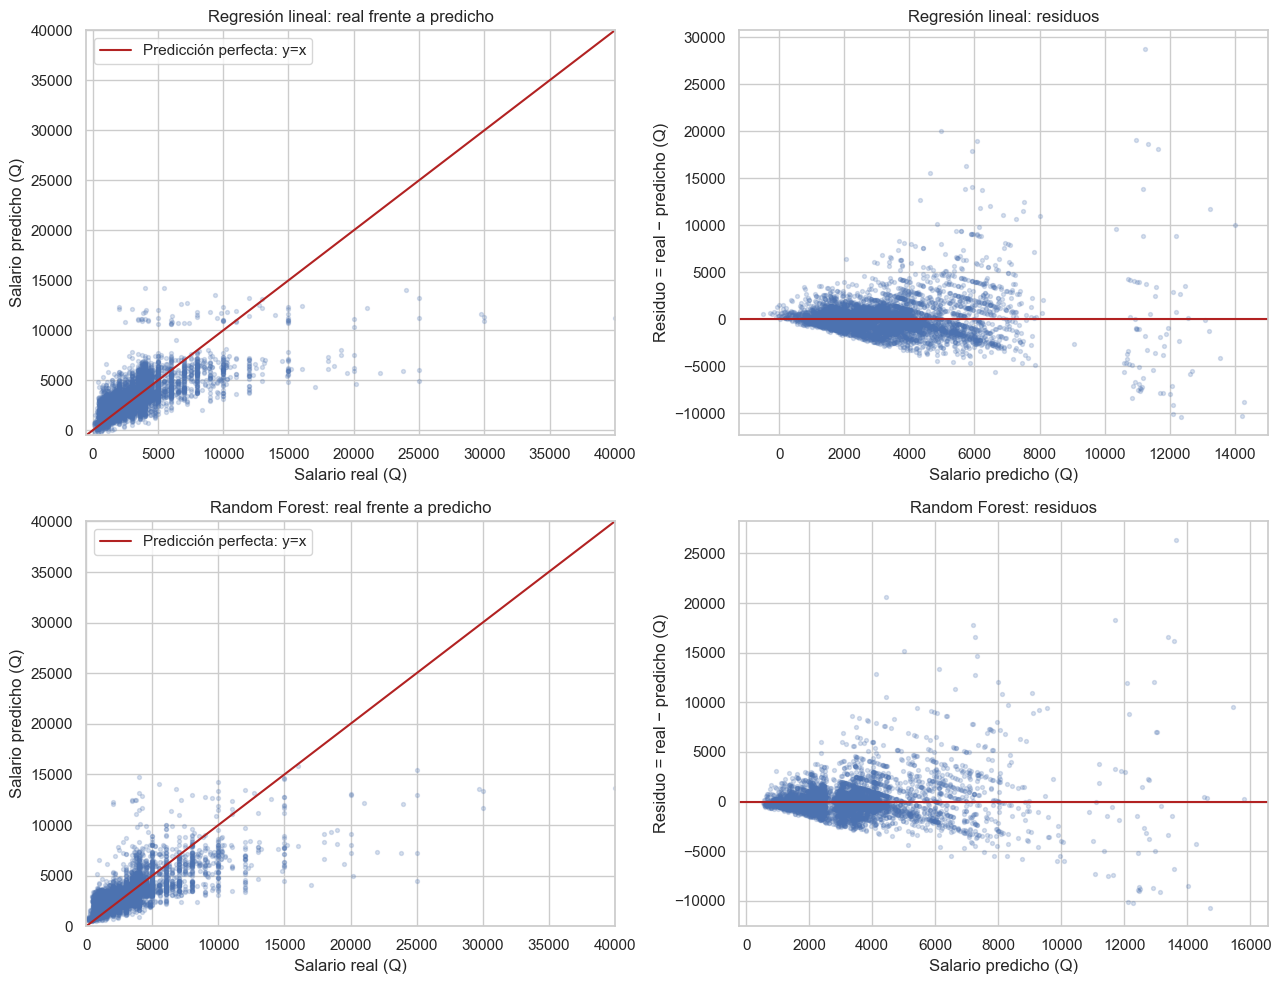

Cada modelo se visualiza con los mismos 5,000 registros. Las métricas usan los 13,258 registros.


In [18]:
TAMANO_GRAFICO = min(5000, n_test)
muestra_visual = prueba.orderBy(F.rand(seed=42)).limit(TAMANO_GRAFICO).cache()
assert muestra_visual.count() == TAMANO_GRAFICO
graficos = {}
for nombre, modelo in [('Regresión lineal', modelo_lineal_final), ('Random Forest', modelo_bosque_final)]:
    graf = modelo.transform(muestra_visual).select('salario_mensual', 'prediction').toPandas()
    graf['residuo'] = graf['salario_mensual'] - graf['prediction']
    graficos[nombre] = graf

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for fila, (nombre, graf) in enumerate(graficos.items()):
    ax_real, ax_residuo = axes[fila]
    ax_real.scatter(graf['salario_mensual'], graf['prediction'], s=8, alpha=0.22)
    minimo = min(0, float(graf['prediction'].min()))
    maximo = max(float(graf['salario_mensual'].max()), float(graf['prediction'].max()))
    ax_real.plot([minimo, maximo], [minimo, maximo], color='firebrick', linewidth=1.5, label='Predicción perfecta: y=x')
    ax_real.set_xlim(minimo, maximo)
    ax_real.set_ylim(minimo, maximo)
    ax_real.set_xlabel('Salario real (Q)')
    ax_real.set_ylabel('Salario predicho (Q)')
    ax_real.set_title(nombre + ': real frente a predicho')
    ax_real.legend(loc='upper left')

    ax_residuo.scatter(graf['prediction'], graf['residuo'], s=8, alpha=0.22)
    ax_residuo.axhline(0, color='firebrick', linewidth=1.5)
    ax_residuo.set_xlabel('Salario predicho (Q)')
    ax_residuo.set_ylabel('Residuo = real − predicho (Q)')
    ax_residuo.set_title(nombre + ': residuos')
plt.tight_layout()
plt.show()
print(f'Cada modelo se visualiza con los mismos {TAMANO_GRAFICO:,} registros. Las métricas usan los {n_test:,} registros.')

In [19]:
def errores_por_grupo(df_pred, variable, nombre_modelo):
    residuos = df_pred.withColumn('residuo', F.col('salario_mensual') - F.col('prediction'))
    agregado = (residuos.groupBy(variable)
        .agg(F.count('*').alias('n'),
             F.avg(F.abs(F.col('residuo'))).alias('MAE_Q'),
             F.avg('residuo').alias('error_medio_Q'))
        .orderBy(variable).toPandas())
    agregado.insert(0, 'modelo', nombre_modelo)
    agregado.insert(1, 'grupo', variable)
    return agregado.rename(columns={variable: 'codigo'})

tablas_grupo = []
for nombre, df_pred in predicciones_test.items():
    for variable in ('nivel_educativo', 'dominio'):
        tablas_grupo.append(errores_por_grupo(df_pred, variable, nombre))
tabla_grupos = pd.concat(tablas_grupo, ignore_index=True)
display(tabla_grupos.round(2))
print('Error medio positivo = subestimación; negativo = sobreestimación.')

,modelo,grupo,codigo,n,MAE_Q,error_medio_Q
0,Regresión lineal,nivel_educativo,0,1016,823.51,109.34
1,Regresión lineal,nivel_educativo,1,80,735.21,88.76
2,Regresión lineal,nivel_educativo,2,3957,870.04,54.56
3,Regresión lineal,nivel_educativo,3,2164,894.45,127.77
4,Regresión lineal,nivel_educativo,4,4117,1109.31,103.98
5,Regresión lineal,nivel_educativo,5,1729,2566.37,295.51
6,Regresión lineal,nivel_educativo,6,183,5552.88,-131.50
7,Regresión lineal,nivel_educativo,7,12,12919.31,6062.70
8,Regresión lineal,dominio,1,5632,1446.09,136.04
9,Regresión lineal,dominio,2,4846,1189.65,134.28


Error medio positivo = subestimación; negativo = sobreestimación.


### Salarios altos y dirección del error

Los cortes P50, P75 y P95 se calculan sobre **todos** los salarios de prueba; no se usan para entrenar ni recortar datos. Se comparan MAE y residuo medio por tramo salarial con todos los registros de cada tramo. La última banda permite observar si los modelos tienden a subestimar o sobreestimar salarios altos.

In [20]:
p50, p75, p95 = prueba.agg(
    F.percentile_approx('salario_mensual', [0.50, 0.75, 0.95], 10000)
).first()[0]
max_salario_prueba = prueba.agg(F.max('salario_mensual')).first()[0]

def errores_por_percentil(df_pred, nombre_modelo):
    banda = (
        F.when(F.col('salario_mensual') < p50, '< P50')
         .when(F.col('salario_mensual') < p75, 'P50–P75')
         .when(F.col('salario_mensual') < p95, 'P75–P95')
         .otherwise('>= P95')
    )
    df = (df_pred.withColumn('banda_salarial', banda)
        .withColumn('residuo', F.col('salario_mensual') - F.col('prediction')))
    tabla = (df.groupBy('banda_salarial')
        .agg(F.count('*').alias('n'),
             F.avg('salario_mensual').alias('salario_medio_Q'),
             F.avg(F.abs(F.col('residuo'))).alias('MAE_Q'),
             F.avg('residuo').alias('error_medio_Q'))
        .toPandas())
    tabla.insert(0, 'modelo', nombre_modelo)
    return tabla

tabla_percentiles = pd.concat(
    [errores_por_percentil(df_pred, nombre) for nombre, df_pred in predicciones_test.items()],
    ignore_index=True,
)
orden_bandas = {'< P50': 0, 'P50–P75': 1, 'P75–P95': 2, '>= P95': 3}
tabla_percentiles['orden'] = tabla_percentiles['banda_salarial'].map(orden_bandas)
tabla_percentiles = tabla_percentiles.sort_values(['modelo', 'orden']).drop(columns='orden')
print(f'2026T1: P50=Q {p50:,.2f}; P75=Q {p75:,.2f}; P95=Q {p95:,.2f}; máximo=Q {max_salario_prueba:,.2f}')
display(tabla_percentiles.round(2))

lecturas_altos = []
for nombre in predicciones_test:
    fila = tabla_percentiles.loc[
        (tabla_percentiles.modelo == nombre) & (tabla_percentiles.banda_salarial == '>= P95')
    ].iloc[0]
    direccion = 'subestima' if fila.error_medio_Q > 0 else 'sobreestima' if fila.error_medio_Q < 0 else 'no muestra sesgo medio'
    lecturas_altos.append(
        f'{nombre}: {direccion} en promedio los salarios de P95 o más '
        f'(error medio Q {fila.error_medio_Q:,.2f}; MAE Q {fila.MAE_Q:,.2f}; n={int(fila.n):,})'
    )
display(Markdown('**Salarios altos.** ' + '; '.join(lecturas_altos) + '.'))

2026T1: P50=Q 3,200.00; P75=Q 4,080.00; P95=Q 8,000.00; máximo=Q 60,000.00


,modelo,banda_salarial,n,salario_medio_Q,MAE_Q,error_medio_Q
6,Random Forest,< P50,6429,1811.92,812.72,-577.57
7,Random Forest,P50–P75,3512,3718.04,700.26,-25.81
4,Random Forest,P75–P95,2505,5247.64,1322.79,682.80
5,Random Forest,>= P95,812,11605.16,4667.64,4388.94
2,Regresión lineal,< P50,6429,1811.92,949.30,-591.84
3,Regresión lineal,P50–P75,3512,3718.04,822.90,-65.55
0,Regresión lineal,P75–P95,2505,5247.64,1308.02,664.72
1,Regresión lineal,>= P95,812,11605.16,5147.33,4887.11


**Salarios altos.** Regresión lineal: subestima en promedio los salarios de P95 o más (error medio Q 4,887.11; MAE Q 5,147.33; n=812); Random Forest: subestima en promedio los salarios de P95 o más (error medio Q 4,388.94; MAE Q 4,667.64; n=812).

### Conclusión general

**Preparación y perfiles.** De 203,676 registros originales de Personas en 2025, 53,025 cumplen todos los criterios del análisis. El salario mediano es **Q 3,000**, la media **Q 3,421.68** y el máximo **Q 99,000**: la cola alta eleva la media. Entre las variables numéricas, antigüedad tiene la mayor correlación lineal con salario (**r = 0.180**), aunque sigue siendo modesta. KMeans eligió **K = 2** (silhouette 0.554): el grupo más joven y de menor antigüedad representa 72.46 % de los registros; el otro, de mayor edad y antigüedad, 27.54 %. La mediana salarial de ambos grupos es Q 3,000 y Q 3,456, respectivamente. El salario se comparó **después** de crear los clústeres.

**Selección de modelos.** Se entrenó con **40,361** registros de 2025T1–T3 y se eligieron configuraciones usando **12,664** de 2025T4. La mejor regresión lineal fue `regParam=0` (RMSE **Q 2,186.42**, MAE Q 1,210.14, R² 0.426). El mejor Random Forest tuvo 60 árboles y profundidad máxima 9 (RMSE **Q 2,032.16**, MAE Q 1,087.79, R² 0.504). Ambos superaron la referencia de la media de entrenamiento (RMSE Q 2,889.57), y Random Forest obtuvo menor error. Su capacidad para captar relaciones no lineales e interacciones puede explicar parte de la mejora; esta comparación no prueba qué variables causan el salario.

**Prueba final.** Tras reentrenar cada pipeline con todo 2025, se evaluaron los mismos **13,258** registros de 2026T1. Random Forest mantuvo el mejor resultado: **MAE Q 1,115.40, RMSE Q 1,999.13 y R² 0.514**. La regresión lineal obtuvo MAE Q 1,240.71, RMSE Q 2,163.75 y R² 0.431. La referencia obtuvo MAE Q 1,718.09 y RMSE Q 2,871.42. Así, Random Forest redujo la RMSE de la referencia aproximadamente **30.4 %** y la de la regresión lineal **7.6 %** en la prueba. La RMSE de prueba fue ligeramente menor que la de validación en ambos algoritmos; eso describe estos cortes, sin garantizar igual rendimiento en períodos futuros.

**Dónde fallan.** En 2026T1, la banda de salario **Q 8,000 o más** incluye 812 registros; el salario máximo es Q 60,000. El residuo medio en esa banda fue **+Q 4,887.11** para regresión lineal y **+Q 4,388.94** para Random Forest: ambos **subestiman** en promedio los salarios altos. Por debajo de la mediana (Q 3,200), ambos tienden a sobreestimar. El MAE de Random Forest es mayor en el dominio urbano metropolitano (Q 1,327.67) que en el rural nacional (Q 787.22). Por educación, el MAE sube de Q 763.10 en primaria a Q 2,300.75 en superior; doctorado registra Q 12,473.57, pero solo hay **12 registros**, por lo que esa cifra es inestable. Estas diferencias pueden reflejar composición y dispersión salarial, sin implicar efectos causales.

Los salarios extremos se conservaron en todas las métricas y no se transformó el objetivo. El análisis es **no ponderado** y se refiere a registros de asalariados con salario positivo; no constituye una estimación oficial de la población guatemalteca ni una recomendación salarial. `FACTOR` se conservó para documentar el diseño muestral, pero no se usó como peso según el alcance del laboratorio.